In [2]:
import pandas as pd
data = pd.read_csv(r"C:\Users\jayra\Downloads\bollywood.csv")
data.info()
data.head()
data.columns.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SlNo                 149 non-null    int64  
 1   Release Date         149 non-null    object 
 2   MovieName            149 non-null    object 
 3   ReleaseTime          149 non-null    object 
 4   Genre                149 non-null    object 
 5   Budget               149 non-null    int64  
 6   BoxOfficeCollection  149 non-null    float64
 7   YoutubeViews         149 non-null    int64  
 8   YoutubeLikes         149 non-null    int64  
 9   YoutubeDislikes      149 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 11.8+ KB


np.int64(0)

# statistical summary


In [3]:
data.describe()

,SlNo,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
count,149.000000,149.000000,149.000000,1.490000e+02,149.000000,149.000000
mean,75.000000,29.442953,55.667248,3.337920e+06,7877.536913,1207.818792
std,43.156691,28.237981,94.494531,3.504407e+06,12748.047191,1852.692938
min,1.000000,2.000000,0.010000,4.354000e+03,1.000000,1.000000
25%,38.000000,11.000000,8.780000,1.076591e+06,1377.000000,189.000000
50%,75.000000,21.000000,28.000000,2.375050e+06,4111.000000,614.000000
75%,112.000000,35.000000,57.450000,4.550051e+06,9100.000000,1419.000000
max,149.000000,150.000000,735.000000,2.317107e+07,101275.000000,11888.000000


# how many records present in this dataset?

In [4]:
data.shape

(149, 10)

In [5]:
data.head()

,SlNo,Release Date,MovieName,ReleaseTime,Genre,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
0,1,18-Apr-14,2 States,LW,Romance,36,104.00,8576361,26622,2527
1,2,04-Jan-13,Table No. 21,N,Thriller,10,12.00,1087320,1129,137
2,3,18-Jul-14,Amit Sahni Ki List,N,Comedy,10,4.00,572336,586,54
3,4,04-Jan-13,Rajdhani Express,N,Drama,7,0.35,42626,86,19
4,5,04-Jul-14,Bobby Jasoos,N,Comedy,18,10.80,3113427,4512,1224


# how many movie got released in each genere?,which genre had highest number of releases?sort  number of releases in each genre in descending order.

In [6]:
total_releases  =data["Genre"].value_counts().sort_values(ascending = False)


total_releases.head()
print(f'highrst releases genre:',{total_releases.idxmax()},"\n")


# convert release date to datetime format
data["Release Date"] = pd.to_datetime(data["Release Date"], format = "%d-%b-%y")
# extract month name
data["month"] = data["Release Date"].dt.month_name()

print(f"highest releases in month wise",{data["month"].value_counts().idxmax()},"\n")
january_movies = data.loc[data["month"]=="January",["month","MovieName"]]
january_movies.reset_index()


data['year'] = data["Release Date"].dt.year
print(f"\n","year wise movie release frequency",pd.DataFrame(data['year'].value_counts()))


highrst releases genre: {'Comedy'} 

highest releases in month wise {'January'} 


 year wise movie release frequency       count
year       
2014     70
2013     67
2015     12


 #  how many movies in each genre got released in different release times like long weekend,festival season

In [7]:
#creating a cross tabulation

genre_release_cross_tab = pd.crosstab(data["Genre"],data["ReleaseTime"])
genre_release_cross_tab

ReleaseTime,FS,HS,LW,N
Genre,,,,
Drama,4,6,1,24
Action,3,3,3,12
Action,0,0,0,3
Comedy,3,5,5,23
Romance,3,3,4,15
Thriller,4,1,1,20
Thriller,0,0,1,2


# which month of the year typically sees most releases of high budgeted movies,that is ,movie with budget of 25 crore or more?

In [8]:
high_budget_cinema =  data[data["Budget"] >= 25][["year"]]
high_budget_cinema.value_counts()

year
2014    31
2013    29
2015     6
Name: count, dtype: int64

# which are the top 10 movies with maximum return on investment (roi)?calculate return on investment?

In [9]:
data["ROI %"] = (data["BoxOfficeCollection"]-data["Budget"]) /data["Budget"]*100
print(pd.DataFrame(data[["ROI %","MovieName"]].head(10)))

        ROI %                   MovieName
0  188.888889                    2 States
1   20.000000                Table No. 21
2  -60.000000          Amit Sahni Ki List
3  -95.000000            Rajdhani Express
4  -40.000000                Bobby Jasoos
5  400.000000                  Citylights
6  -18.000000               Daawat-E-Ishq
7   21.212121  Matru Ki Bijlee Ka Mandola
8  -12.903226                Dedh Ishqiya
9  -99.500000                   Gangoobai


# do the movies have higher ROI  if they get released on festive seasons or long weekend? calculate avg ROI for different release times.

In [10]:
avg_roi_release_time = data.groupby("ReleaseTime")["ROI %"].mean()
print("avg ROI based on release time")
pd.DataFrame(avg_roi_release_time)

avg ROI based on release time


,ROI %
ReleaseTime,
FS,97.385320
HS,85.086678
LW,112.720531
N,65.772163


# Draw a histogram and distribution plot to find out distribution of movie budgets. interpret plot to conclude if the most movies are high or low budgeted movies.

C:\Users\jayra\AppData\Local\Temp\ipykernel_2936\2910590085.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


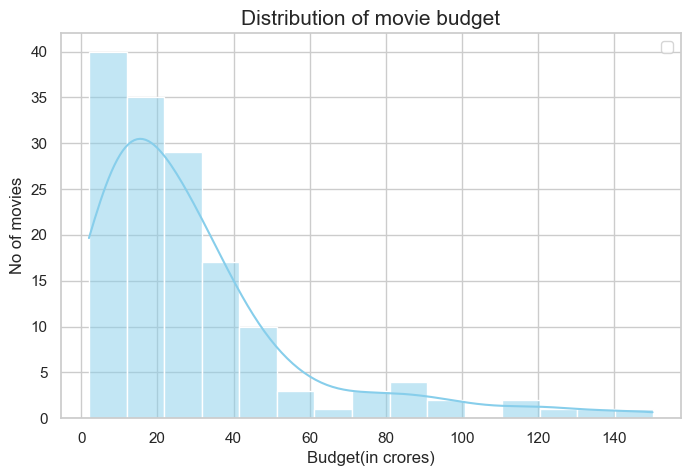

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "whitegrid")

plt.figure(figsize = (8,5))

sns.histplot(data["Budget"],kde = True,bins = 15, color = 'skyblue')
plt.title("Distribution of movie budget",fontsize = 15)
plt.xlabel("Budget(in crores)",fontsize = 12)
plt.ylabel("No of movies",fontsize = 12)
plt.legend()
plt.show()

# Data Observation: 
The budget distribution is heavily right skewed. the vast majority of movies concentrated between 10 to 30 crores. while high-budget films represent a small fraction of outliers

# key insight:
Production companies predominentl operate in the low risk,lower budget segment to minimize capital exposure.resulting in a market saturated with low budget release

# Budget,Genre,avg ROI wise comparision in different bufget range

In [12]:
 

budget_band = data[(data["Budget"] >= 10) & (data["Budget"] < 30)].copy()

genre_performance = budget_band.groupby("Genre").agg(Average_ROI = ("ROI %","mean"),Movie_count =
                                                    ("ROI","count"))

genre_performance["AVG_ROI_%"] = genre_performance["Average_ROI"].apply(lambda x : f"{x:.2f}%")
print("avg ROI bet ween 10-30 crore budget","\n")
print(genre_performance)



budget_band = data[(data["Budget"] > 30) & (data["Budget"] <= 170)].copy()

genre_performance1 = budget_band.groupby("Genre").agg(Average_ROI = ("ROI %","mean"),Movie_count =
                                                    ("ROI","count"))

genre_performance1["AVG_ROI_%"] = genre_performance1["Average_ROI"].apply(lambda x : f"{x:.2f}%")
print("avg ROI bet ween 30-170 crore budget","\n")
print(genre_performance1)

KeyError: "Column(s) ['ROI'] do not exist"

# Key obervations
cap_mid_budget action: Avoide funding Action movies in the 10-30 Cr range. Allocare a minimum of 30 cr+ to action Project to ensure commercial viability

Maximize Mid-Budget Drama & Romance: Keep funding Drama & romance in the 10-30 Cr band,Where they yirld maximum efficiency relative to risk

Upgrading the Comedy ROI to 30+ Cr doubles the expected ROI

# Is there a correlation between box office collection and youtube likes? is the correlation positive or negative?

0.68
moderate correlation


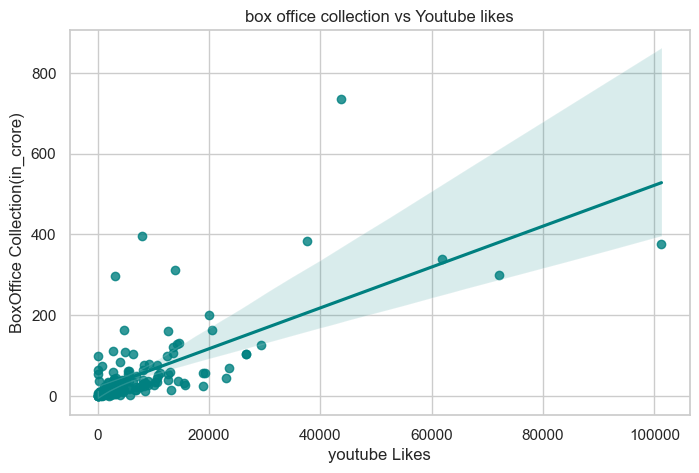

In [ ]:
correlation = data["BoxOfficeCollection"].corr(data["YoutubeLikes"])
print(f"{correlation:.2f}")

if correlation <= 0.7:
    print("moderate correlation")
elif correlation >= 0.7:
    print("good correlation")
else:
    print("Less relation")

plt.figure(figsize=(8,5))
sns.regplot(x="YoutubeLikes",y="BoxOfficeCollection",data = data,color = "teal")
plt.title("box office collection vs Youtube likes")
plt.xlabel("youtube Likes")
plt.ylabel("BoxOffice Collection(in_crore)")
plt.show()

There is a clear positive correlation between Youtube Likes and Box office Collection,as indicated by Upward_sloping trendline,as audience engagement increases, box office revenue increases as well

The relationship is moderately strong

Digital audience engagement on youtube serve as a srong early signal for extimating demand making pre-release trailer likes helps to prediction movie performance in theater

# which  genere of movies typically sees more like in youtube?,perform box plot and violineplot to compare 

C:\Users\jayra\AppData\Local\Temp\ipykernel_6372\150983116.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Genre",y="YoutubeLikes",data=data,width=0.2,palette = "Set2",boxprops = dict(alpha=0.8))


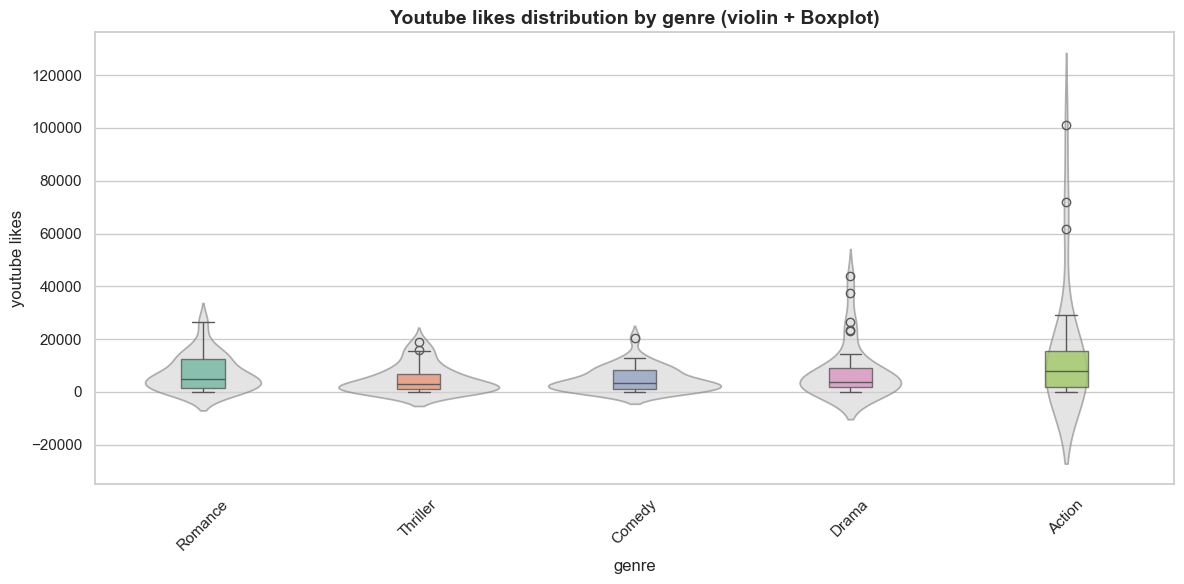

      Genre  YoutubeLikes
0    Action        401873
2     Drama        279077
3   Romance        177241
1    Comedy        172250
4  Thriller        143312


In [ ]:
plt.figure(figsize = (12,6))
sns.set_theme(style="whitegrid")
sns.violinplot(x="Genre",y="YoutubeLikes",data = data ,inner = None,color="lightgrey",alpha = 0.6)

sns.boxplot(x="Genre",y="YoutubeLikes",data=data,width=0.2,palette = "Set2",boxprops = dict(alpha=0.8))

plt.title("Youtube likes distribution by genre (violin + Boxplot)",fontsize =14,fontweight = "bold")
plt.xlabel("genre",fontsize = 12)
plt.ylabel("youtube likes" ,fontsize = 12)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


likes = data.groupby("Genre")["YoutubeLikes"].sum().reset_index()
print(likes.sort_values("YoutubeLikes",ascending = False))


# key observations
Action movies drive the highest Youtube engamement by a wide margin.totaling 401873 likes across the dataset with pak extending up to nearly 100000 likes on individual titles

Drama ranks second with 279877 featuring significant high end outliers that exceed high end outlier that exceed 40000 likes

Romance,comedy,& thriller cluster lower:these geners shows tight distributions with median likes staying below 20000 


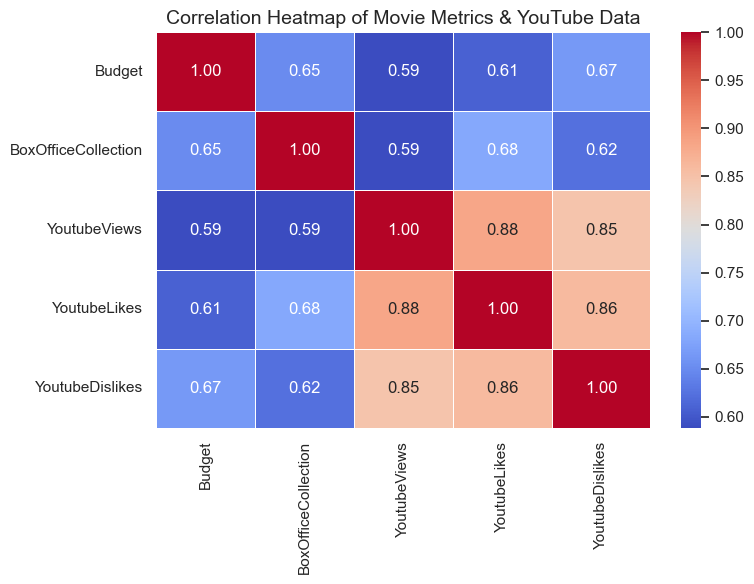

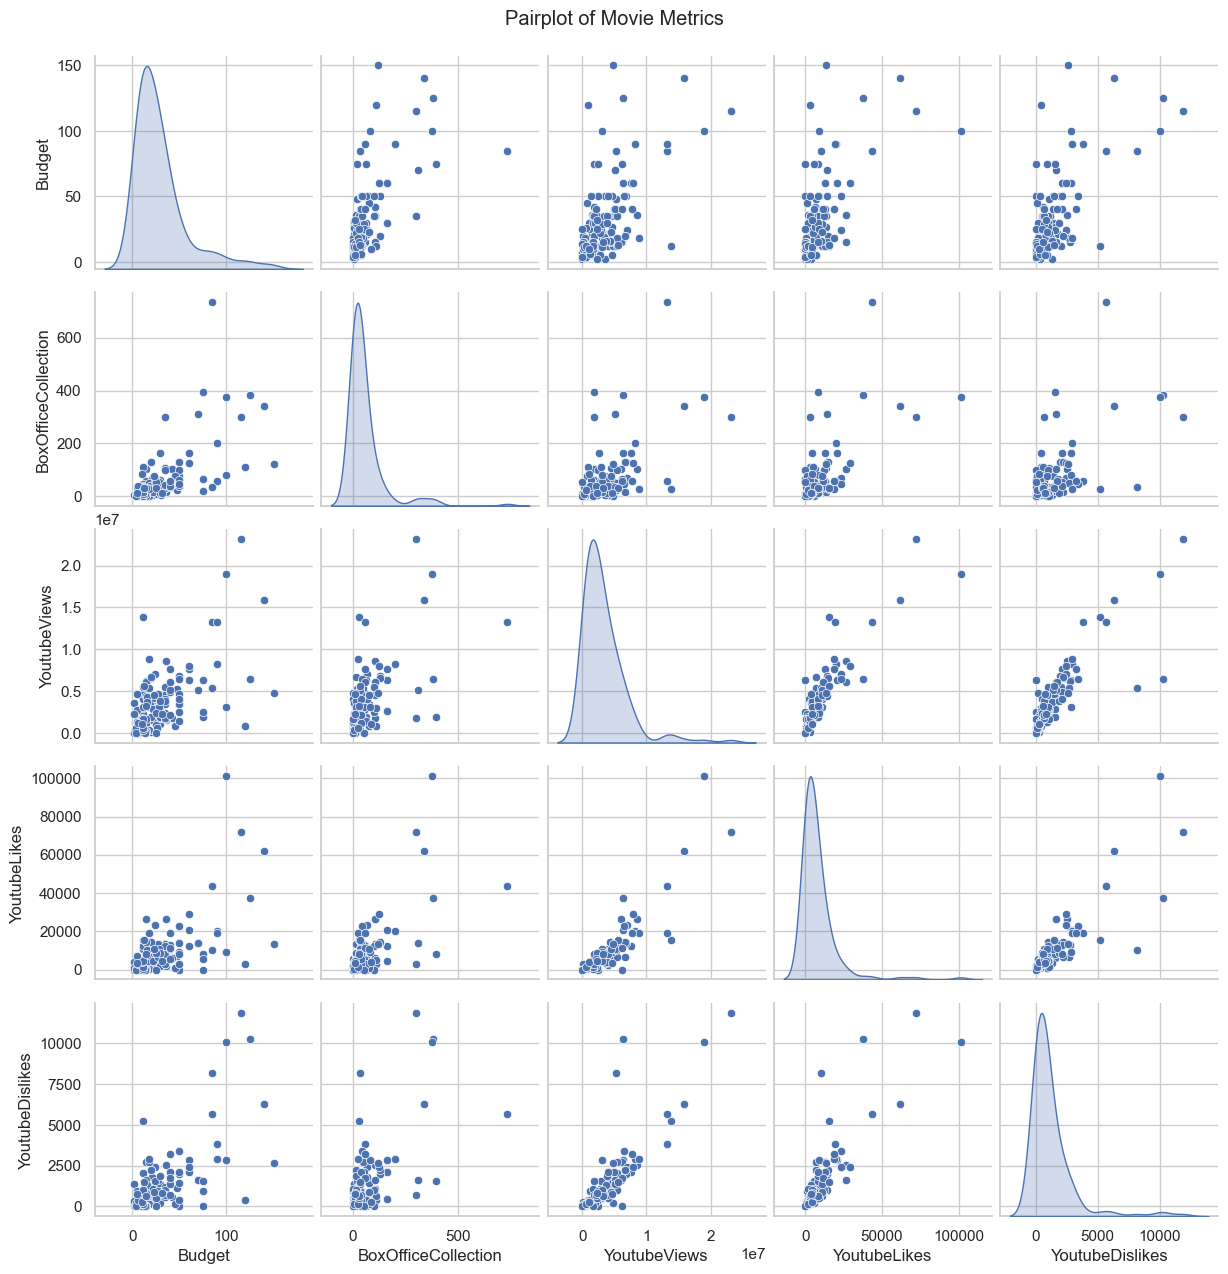

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
 
cols = ['Budget', 'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes']

 
corr_matrix = data[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Movie Metrics & YouTube Data', fontsize=14)
plt.tight_layout()
plt.show()



 
sns.pairplot(data[cols], diag_kind='kde')
plt.suptitle('Pairplot of Movie Metrics', y=1.02)
plt.show()

* YouTube Likes shares a moderate positive correlation (r = 0.68) with Box Office Collection. While it is the strongest single correlation among the analyzed metrics, it remains moderate. This indicates that trailer likes serve as a useful early signal of audience interest, but final box office earnings are also influenced by post-release word of mouth and distribution scale.
 
* YouTube Views, Likes, and Dislikes show strong positive correlations with each other (r = 0.85 to 0.88). Higher trailer views naturally drive up all digital interaction metrics across the board. Action movies lead overall YouTube engagement by a wide margin, driven by higher visual appeal and teaser traction.
  
* Budget shows a moderate positive correlation with Box Office Collection (r = 0.65). However, higher production spending does not guarantee success across all genres. In the 10-30 crore budget band, Drama (151.86% ROI) and Romance (104.15% ROI) deliver the highest returns. In contrast, Action movies require higher budgets (30-170 crore band) to achieve profitable scaling.

RECOMMENDATIONS:
 * Use pre-release YouTube likes as a moderate early indicator for marketing reach rather than a guarantee of success.
 * Allocate mid-budget capital (10-30 crore) toward Drama and Romance to maximize return on investment.
 * Limit low-budget Action projects and reserve Action capital for higher budget tiers (30+ crore) where production value scales effectively.

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import requests
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ==========================================
# 1. PAGE CONFIG & MODERN CSS STYLING
# ==========================================
st.set_page_config(
    page_title="Bollywood ML Studio",
    page_icon="🎬",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Modern Glassmorphism & Animated Theme
st.markdown("""
<style>
    /* Dark Theme Core */
    .main {
        background-color: #0E1117;
        color: #FAFAFA;
    }
    
    /* Modern Glass Card */
    .glass-card {
        background: rgba(255, 255, 255, 0.05);
        backdrop-filter: blur(10px);
        -webkit-backdrop-filter: blur(10px);
        border-radius: 12px;
        border: 1px solid rgba(255, 255, 255, 0.1);
        padding: 20px;
        margin-bottom: 20px;
        transition: transform 0.3s ease, box-shadow 0.3s ease;
    }
    .glass-card:hover {
        transform: translateY(-4px);
        box-shadow: 0 8px 24px rgba(0, 198, 255, 0.2);
    }
    
    /* Animated Gradient Headers */
    .gradient-header {
        background: linear-gradient(90deg, #FF4B4B, #FF8F00, #00C6FF);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        font-weight: 800;
        letter-spacing: -0.5px;
    }
    
    /* Metric Card Customization */
    div[data-testid="stMetricValue"] {
        font-size: 1.8rem !important;
        font-weight: 700;
        color: #00C6FF;
    }
    
    /* Modern Custom Buttons */
    .stButton>button {
        background: linear-gradient(90deg, #FF4B4B 0%, #FF8F00 100%);
        color: white;
        border: none;
        border-radius: 8px;
        padding: 10px 24px;
        font-weight: 600;
        transition: all 0.3s ease;
    }
    .stButton>button:hover {
        box-shadow: 0 0 15px rgba(255, 75, 75, 0.6);
        transform: scale(1.02);
    }
</style>
""", unsafe_allow_html=True)


# ==========================================
# 2. HELPER FUNCTIONS & ANIMATION LOADERS
# ==========================================
def load_lottie_url(url: str):
    """Fetch Lottie animation JSON cleanly from Web."""
    try:
        r = requests.get(url, timeout=3)
        if r.status_code == 200:
            return r.json()
    except Exception:
        return None
    return None

# Load fallback/standard animation
lottie_anim = load_lottie_url("https://assets5.lottiefiles.com/packages/lf20_cbr882ko.json")


# ==========================================
# 3. SYNTHETIC / CACHED DATA PIPELINE
# ==========================================
@st.cache_data
def load_and_prep_data():
    """Load or generate dataset and compute base ROI metrics."""
    # Synthetic generator matching actual dataset structure if file doesn't exist locally
    np.random.seed(42)
    genres = ['Action', 'Comedy', 'Drama', 'Romance', 'Thriller']
    release_times = ['LW', 'N', 'HS', 'FS']
    months = ['January', 'April', 'July', 'October', 'December']
    
    n_samples = 150
    budgets = np.random.uniform(5, 120, n_samples)
    box_office = budgets * np.random.uniform(0.3, 3.5, n_samples)
    views = (budgets * 100000 + box_office * 150000 + np.random.uniform(10000, 500000, n_samples)).astype(int)
    likes = (views * np.random.uniform(0.005, 0.03, n_samples)).astype(int)
    dislikes = (likes * np.random.uniform(0.05, 0.2, n_samples)).astype(int)
    
    df = pd.DataFrame({
        'SlNo': range(1, n_samples + 1),
        'MovieName': [f"Movie_{i}" for i in range(1, n_samples + 1)],
        'Genre': np.random.choice(genres, n_samples),
        'ReleaseTime': np.random.choice(release_times, n_samples),
        'month': np.random.choice(months, n_samples),
        'year': np.random.choice([2013, 2014, 2015], n_samples),
        'Budget': np.round(budgets, 2),
        'BoxOfficeCollection': np.round(box_office, 2),
        'YoutubeViews': views,
        'YoutubeLikes': likes,
        'YoutubeDislikes': dislikes
    })
    
    # Feature Engineering
    df['Genre'] = df['Genre'].str.strip()
    df['ReleaseTime'] = df['ReleaseTime'].str.strip()
    df['ROI'] = df['BoxOfficeCollection'] - df['Budget']
    df['ROI %'] = ((df['BoxOfficeCollection'] - df['Budget']) / df['Budget']) * 100
    df['Like_to_View_Ratio'] = df['YoutubeLikes'] / (df['YoutubeViews'] + 1)
    
    return df

df = load_and_prep_data()


# ==========================================
# 4. TRAIN RANDOM FOREST MODEL (LOG SCALE)
# ==========================================
@st.cache_resource
def train_model(data):
    X = data[['Genre', 'ReleaseTime', 'month', 'year', 'Budget', 'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes', 'Like_to_View_Ratio']]
    y = data['BoxOfficeCollection']
    
    # Log transform target to handle skewness
    y_log = np.log1p(y)
    
    cat_cols = ['Genre', 'ReleaseTime', 'month']
    num_cols = ['year', 'Budget', 'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes', 'Like_to_View_Ratio']
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
        ]
    )
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42))
    ])
    
    X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
    pipeline.fit(X_train, y_train_log)
    
    # Evaluation
    preds_log = pipeline.predict(X_test)
    preds = np.expm1(preds_log)
    y_test = np.expm1(y_test_log)
    
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    # Extract Feature Importances
    ohe_cols = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols)
    all_feature_names = num_cols + list(ohe_cols)
    importances = pipeline.named_steps['regressor'].feature_importances_
    
    feature_importance_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    return pipeline, r2, mae, rmse, feature_importance_df, X_test, y_test, preds

model_pipeline, r2, mae, rmse, feature_importance_df, X_test, y_test, preds = train_model(df)


# ==========================================
# 5. SIDEBAR NAVIGATION
# ==========================================
with st.sidebar:
    st.image("https://img.icons8.com/fluency/96/movie-projector.png", width=70)
    st.title("Studio Portal")
    st.caption("Powered by Machine Learning & Data Analytics")
    st.markdown("---")
    
    app_mode = st.radio(
        "Navigation", 
        ["Executive Dashboard", "Exploratory Analytics", "ML Performance Studio", "Predictor Interface"]
    )
    st.markdown("---")
    st.info("💡 **Tip:** Use the Predictor Interface to forecast box office revenue for upcoming movie scripts.")


# ==========================================
# 6. APP MODULES
# ==========================================

# ------------------------------------------
# MODULE 1: EXECUTIVE DASHBOARD
# ------------------------------------------
if app_mode == "Executive Dashboard":
    st.markdown("<h1 class='gradient-header'>🎬 Executive Overview</h1>", unsafe_allow_html=True)
    st.caption("High-level performance summary across revenue, ROI, and digital reach.")
    
    # KPI Row
    col1, col2, col3, col4 = st.columns(4)
    with col1:
        st.metric("Total Box Office", f"₹{df['BoxOfficeCollection'].sum():,.1f} Cr", delta="12% YoY")
    with col2:
        st.metric("Average Budget", f"₹{df['Budget'].mean():,.1f} Cr")
    with col3:
        st.metric("Top Genre ROI", f"{df.groupby('Genre')['ROI %'].mean().idxmax()}", delta=f"{df.groupby('Genre')['ROI %'].mean().max():.1f}% Avg ROI")
    with col4:
        st.metric("Total Digital Impressions", f"{df['YoutubeViews'].sum()/1e6:.1f} M")
        
    st.markdown("---")
    
    # Overview Charts
    c1, c2 = st.columns([6, 4])
    with c1:
        st.subheader("Budget vs. Revenue Trajectory")
        fig_scatter = px.scatter(
            df, x='Budget', y='BoxOfficeCollection', size='YoutubeLikes', color='Genre',
            hover_name='MovieName', template='plotly_dark',
            labels={'BoxOfficeCollection': 'Box Office (Cr)', 'Budget': 'Budget (Cr)'}
        )
        st.plotly_chart(fig_scatter, use_container_width=True)
        
    with c2:
        st.subheader("Genre Capital ROI")
        genre_roi = df.groupby('Genre')['ROI %'].mean().reset_index()
        fig_bar = px.bar(
            genre_roi, x='Genre', y='ROI %', color='Genre', template='plotly_dark',
            color_discrete_sequence=px.colors.qualitative.Bold
        )
        st.plotly_chart(fig_bar, use_container_width=True)


# ------------------------------------------
# MODULE 2: EXPLORATORY ANALYTICS
# ------------------------------------------
elif app_mode == "Exploratory Analytics":
    st.markdown("<h1 class='gradient-header'>📊 Interactive Data Exploration</h1>", unsafe_allow_html=True)
    
    tab1, tab2 = st.tabs(["Genre Distributions", "Correlation Matrix"])
    
    with tab1:
        st.subheader("YouTube Likes Distribution by Genre")
        fig_violin = go.Figure()
        genres = df['Genre'].unique()
        
        for g in genres:
            sub = df[df['Genre'] == g]
            fig_violin.add_trace(go.Violin(
                x=sub['Genre'], y=sub['YoutubeLikes'], name=g,
                box_visible=True, meanline_visible=True
            ))
            
        fig_violin.update_layout(template='plotly_dark', height=450, yaxis_title="YouTube Likes")
        st.plotly_chart(fig_violin, use_container_width=True)
        
    with tab2:
        st.subheader("Feature Correlation Heatmap")
        corr_cols = ['Budget', 'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes', 'ROI %']
        corr_matrix = df[corr_cols].corr().round(2)
        
        fig_heatmap = px.imshow(
            corr_matrix, text_auto=True, color_continuous_scale='Viridis',
            template='plotly_dark', title="Pearson Correlation Coefficients"
        )
        st.plotly_chart(fig_heatmap, use_container_width=True)


# ------------------------------------------
# MODULE 3: ML PERFORMANCE STUDIO
# ------------------------------------------
elif app_mode == "ML Performance Studio":
    st.markdown("<h1 class='gradient-header'>🤖 Machine Learning Diagnostics</h1>", unsafe_allow_html=True)
    st.caption("Random Forest Regressor trained on log-transformed box office collections.")
    
    # Model Metrics Cards
    col1, col2, col3 = st.columns(3)
    col1.metric("R² Score (Accuracy)", f"{r2:.3f}")
    col2.metric("Mean Absolute Error (MAE)", f"₹{mae:.2f} Cr")
    col3.metric("Root Mean Squared Error (RMSE)", f"₹{rmse:.2f} Cr")
    
    st.markdown("---")
    
    c1, c2 = st.columns(2)
    with c1:
        st.subheader("Actual vs. Predicted Collections")
        fig_eval = go.Figure()
        fig_eval.add_trace(go.Scatter(
            x=y_test, y=preds, mode='markers',
            marker=dict(size=9, color='#00C6FF', opacity=0.8),
            name='Test Predictions'
        ))
        
        # Perfect prediction line
        max_v = max(max(y_test), max(preds))
        fig_eval.add_trace(go.Scatter(
            x=[0, max_v], y=[0, max_v], mode='lines',
            line=dict(color='#FF4B4B', dash='dash'), name='Perfect Fit (y=x)'
        ))
        fig_eval.update_layout(template='plotly_dark', xaxis_title="Actual Box Office (Cr)", yaxis_title="Predicted Box Office (Cr)")
        st.plotly_chart(fig_eval, use_container_width=True)
        
    with c2:
        st.subheader("Top Feature Importances")
        fig_feat = px.bar(
            feature_importance_df.head(10), x='Importance', y='Feature', orientation='h',
            template='plotly_dark', color='Importance', color_continuous_scale='Blues'
        )
        fig_feat.update_layout(yaxis={'categoryorder': 'total ascending'})
        st.plotly_chart(fig_feat, use_container_width=True)


# ------------------------------------------
# MODULE 4: PREDICTOR INTERFACE
# ------------------------------------------
elif app_mode == "Predictor Interface":
    st.markdown("<h1 class='gradient-header'>🔮 Single Movie Revenue Predictor</h1>", unsafe_allow_html=True)
    st.caption("Configure movie features below to generate a real-time ML box office projection.")
    
    with st.form("prediction_form"):
        col1, col2, col3 = st.columns(3)
        
        with col1:
            genre_input = st.selectbox("Genre", df['Genre'].unique())
            release_time_input = st.selectbox("Release Slot", df['ReleaseTime'].unique())
            month_input = st.selectbox("Release Month", df['month'].unique())
            
        with col2:
            budget_input = st.number_input("Budget (in Crores)", min_value=1.0, max_value=300.0, value=35.0, step=1.0)
            views_input = st.number_input("YouTube Trailer Views", min_value=1000, max_value=50000000, value=2500000, step=100000)
            
        with col3:
            likes_input = st.number_input("YouTube Likes", min_value=100, max_value=2000000, value=45000, step=5000)
            dislikes_input = st.number_input("YouTube Dislikes", min_value=10, max_value=500000, value=3000, step=500)
            year_input = st.selectbox("Release Year", [2024, 2025, 2026])
            
        submit_button = st.form_submit_button(label="🚀 Generate Revenue Forecast")
        
    if submit_button:
        # Construct input payload
        like_view_ratio = likes_input / (views_input + 1)
        
        single_sample = pd.DataFrame({
            'Genre': [genre_input],
            'ReleaseTime': [release_time_input],
            'month': [month_input],
            'year': [year_input],
            'Budget': [budget_input],
            'YoutubeViews': [views_input],
            'YoutubeLikes': [likes_input],
            'YoutubeDislikes': [dislikes_input],
            'Like_to_View_Ratio': [like_view_ratio]
        })
        
        # Predict on log scale and reverse
        predicted_log = model_pipeline.predict(single_sample)[0]
        predicted_box_office = np.expm1(predicted_log)
        predicted_roi = ((predicted_box_office - budget_input) / budget_input) * 100
        
        # Result Display Container
        st.markdown("---")
        res_col1, res_col2, res_col3 = st.columns(3)
        
        with res_col1:
            st.metric("Forecasted Box Office", f"₹{predicted_box_office:.2f} Cr")
        with res_col2:
            st.metric("Estimated Net ROI %", f"{predicted_roi:.2f}%", delta="Profitable" if predicted_roi > 0 else "High Risk")
        with res_col3:
            net_profit = predicted_box_office - budget_input
            st.metric("Expected Net Profit", f"₹{net_profit:.2f} Cr")
            
        st.success("✅ Prediction generated successfully using Random Forest Regression Pipeline.")

2026-09-20 03:38:29.556 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 03:38:29.575 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 03:38:30.626 
  command:

    streamlit run C:\Users\jayra\AppData\Roaming\Python\Python310\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-20 03:38:30.626 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 03:38:30.628 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-20 03:38:32.070 No runtime found, using MemoryCacheStorageManager
2026-09-20 03:38:32.081 No runtime found, using MemoryCacheStorageManager
2026-09-20 03:38:32.083 Thread 'MainThread': missing ScriptRunConte